# Backcasting analysis — load-first cleaned version

This notebook is structured to avoid repeating expensive raster operations. By default, it loads all written intermediate products that are already available on disk and only runs plotting / summary steps based on these loaded products.

Set `RUN_EXPENSIVE_IF_MISSING = True` only if you deliberately want to rebuild missing products. Otherwise, missing heavy products are reported and skipped rather than recomputed.


In [1]:
# ------------------------------------------------------------
# Imports and global settings
# ------------------------------------------------------------
from pathlib import Path
from collections import Counter
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
from rasterio.warp import reproject

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import Polygon, box
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde

try:
    import xarray as xr
    import rioxarray  # noqa: F401
except ImportError:
    xr = None

# ------------------------------------------------------------
# Behaviour switches
# ------------------------------------------------------------
RUN_EXPENSIVE_IF_MISSING = False   # keep False to avoid heavy raster computations
OVERWRITE_OUTPUTS = True           # only affects figures / small summary tables

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
old_growth_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif")
old_growth_nodata0_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif")
prob_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif")
slope_fp = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/slope_NBR_1985_1995_mosaic.vrt")
undist_fp = Path("/mnt/eo/EFDA_v211/undisturbed_forest.tif")
forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")
genus_fp = Path("/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif")
country_gpkg_10m = Path("/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg")
country_gpkg_20m = Path("/mnt/eo/EO4Backcasting/_data/CNTR_RG_20M_2024_3035.gpkg")
forest_age_nc = Path("/mnt/eo/EO4Backcasting/_data/forest_age/GAMIv2-1_2010-2020_100m.nc")

# Forest-age comparison settings
# A stand that pre-dates 1965 must be at least 55 years old in the 2020 forest-age layer.
forest_continuity_start_year = 1965
forest_age_reference_year = 2020
age_threshold = forest_age_reference_year - forest_continuity_start_year

# ------------------------------------------------------------
# Output/cache folders
# ------------------------------------------------------------
fig_dir = Path("/mnt/eo/EO4Backcasting/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

prob_genus_fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/genus_probability")
prob_genus_fig_dir.mkdir(parents=True, exist_ok=True)

cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
cache_dir.mkdir(parents=True, exist_ok=True)

threshold_dir = Path("/mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity")
forest_age_dir = Path("/mnt/eo/EO4Backcasting/_analysis/forest_age_comparison")
session_backup_dir = Path("/mnt/eo/EO4Backcasting/_analysis/session_backups")
aligned_dir = Path("/mnt/eo/EO4Backcasting/_data_aligned")
aligned_dir.mkdir(parents=True, exist_ok=True)

genus_aligned_fp = aligned_dir / "genus_map_europe_aligned_to_probability_30m.tif"

forest_age_2020_member1_europe_fp = (
    aligned_dir / "GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif"
)

hex_compare_gpkg = (
    forest_age_dir / f"hex_continuity_vs_forest_age_ge_{age_threshold}_member1_same_denominator.gpkg"
)
hex_compare_csv = (
    forest_age_dir / f"hex_continuity_vs_forest_age_ge_{age_threshold}_member1_same_denominator.csv"
)

# ------------------------------------------------------------
# Known cached analysis products
# ------------------------------------------------------------
nbr_sample_csv = cache_dir / "nbr_trend_sample_oldgrowth_vs_undisturbed.csv"
genus_counts_csv = cache_dir / "continuously_undisturbed_area_by_genus.csv"
genus_country_csv = cache_dir / "continuously_undisturbed_area_by_genus_country.csv"
genus_share_csv = cache_dir / "continuously_undisturbed_share_by_genus.csv"
country_share_csv = cache_dir / "continuously_undisturbed_share_by_country.csv"
hex_gpkg = cache_dir / "continuously_undisturbed_by_small_clipped_hexagon.gpkg"
prob_genus_sample_csv = cache_dir / "probability_by_genus_sample.csv"
prob_genus_summary_csv = cache_dir / "probability_by_genus_summary.csv"

# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------
pixel_area_ha = 0.09       # 30 m pixel = 900 m² = 0.09 ha
forest_value = 1
country_name_col = "NAME_ENGL"
exclude_russia = True
hex_radius = 17_500
min_forest_area_ha = 500

forest_label = "continuously undisturbed forest"
forest_label_cap = "Continuously undisturbed forest"

genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees",
}

genus_colors = {
    "Picea": "#2C7FB8",
    "Pinus": "#F28E2B",
    "Fagus": "#59A14F",
    "Quercus": "#E15759",
    "Larix": "#B07AA1",
    "Other broadleaf": "#76B7B2",
    "Other needleleaf": "#EDC948",
    "Other": "#BDBDBD",
}

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
    "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

mainland_bbox_4326 = box(-11, 34, 35, 72)

print("Load-first mode. Expensive recomputation enabled:", RUN_EXPENSIVE_IF_MISSING)


Load-first mode. Expensive recomputation enabled: False


In [2]:
# ------------------------------------------------------------
# Small, safe loading helpers
# ------------------------------------------------------------
def path_exists(fp):
    fp = Path(fp)
    return fp.exists()


def read_csv_if_exists(fp, **kwargs):
    fp = Path(fp)
    if fp.exists():
        df = pd.read_csv(fp, **kwargs)
        print(f"Loaded CSV: {fp}  shape={df.shape}")
        return df
    print(f"Missing CSV: {fp}")
    return None


def read_gpkg_if_exists(fp, layer=None, **kwargs):
    fp = Path(fp)
    if fp.exists():
        try:
            gdf = gpd.read_file(fp, layer=layer, **kwargs) if layer else gpd.read_file(fp, **kwargs)
            layer_msg = f", layer={layer}" if layer else ""
            print(f"Loaded GPKG: {fp}{layer_msg}  shape={gdf.shape}")
            return gdf
        except Exception as e:
            print(f"Could not load GPKG {fp}: {e}")
            return None
    print(f"Missing GPKG: {fp}")
    return None


def save_fig(fig, out_base, dpi=600):
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    png = out_base.with_suffix(".png")
    svg = out_base.with_suffix(".svg")
    if OVERWRITE_OUTPUTS or not png.exists():
        fig.savefig(png, dpi=dpi, bbox_inches="tight", facecolor="white")
    if OVERWRITE_OUTPUTS or not svg.exists():
        fig.savefig(svg, bbox_inches="tight", facecolor="white")
    print("Saved PNG:", png)
    print("Saved SVG:", svg)


def require(obj, name):
    if obj is None:
        raise RuntimeError(f"Required object `{name}` is missing. Load the cached file first or enable recomputation.")
    return obj


def add_genus_names(df, code_col="genus_code"):
    df = df.copy()
    df["genus"] = df[code_col].map(genus_lookup)
    df["genus"] = df["genus"].fillna("Code " + df[code_col].astype(str))
    return df


def create_hex_grid(bounds, hex_radius, crs):
    minx, miny, maxx, maxy = bounds
    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius
    hexagons = []
    hex_ids = []
    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1
    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy
        while y < maxy + dy:
            cy = y + y_offset
            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [(x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a)) for a in angles]
            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1
            y += dy
        x += dx
        col += 1
    return gpd.GeoDataFrame({"hex_id": hex_ids}, geometry=hexagons, crs=crs)


def load_europe_countries(target_crs=None, clip_mainland=False, prefer_20m=False):
    country_gpkg = country_gpkg_20m if prefer_20m and country_gpkg_20m.exists() else country_gpkg_10m
    countries = gpd.read_file(country_gpkg)
    countries["country"] = countries[country_name_col].astype(str).str.strip()
    countries = countries[countries["country"].isin(european_countries)].copy()
    if exclude_russia:
        countries = countries[countries["country"] != "Russian Federation"].copy()
    countries = countries[countries.geometry.notna() & ~countries.geometry.is_empty].copy()
    countries["geometry"] = countries.geometry.make_valid()

    if clip_mainland:
        countries_4326 = countries.to_crs(4326)
        parts = countries_4326.explode(index_parts=False).reset_index(drop=True)
        rep = parts.representative_point()
        keep = (rep.x >= -11) & (rep.x <= 35) & (rep.y >= 34) & (rep.y <= 72)
        parts = parts.loc[keep].copy()
        bbox_gdf = gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)
        parts = gpd.clip(parts, bbox_gdf)
        countries = parts.dissolve(by="country", as_index=False)

    if target_crs is not None and countries.crs != target_crs:
        countries = countries.to_crs(target_crs)
    return countries


def ensure_aligned_genus():
    if genus_aligned_fp.exists():
        print(f"Using existing aligned genus raster: {genus_aligned_fp}")
        return genus_aligned_fp

    if not RUN_EXPENSIVE_IF_MISSING:
        print(f"Aligned genus raster missing and recomputation disabled: {genus_aligned_fp}")
        return None

    print("Creating aligned genus raster. This can be expensive.")
    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        profile = prob_src.profile.copy()
        profile.update(
            dtype="uint8", count=1, nodata=255, compress="deflate",
            tiled=True, blockxsize=512, blockysize=512, BIGTIFF="YES",
        )
        with rasterio.open(genus_aligned_fp, "w", **profile) as dst:
            reproject(
                source=rasterio.band(genus_src, 1), destination=rasterio.band(dst, 1),
                src_transform=genus_src.transform, src_crs=genus_src.crs, src_nodata=genus_src.nodata,
                dst_transform=prob_src.transform, dst_crs=prob_src.crs, dst_nodata=255,
                resampling=Resampling.nearest,
            )
    print(f"Written: {genus_aligned_fp}")
    return genus_aligned_fp

# ------------------------------------------------------------
# Forest-age preprocessing and aggregation helpers
# ------------------------------------------------------------
def extract_forest_age_2020_member1_europe(
    nc_fp=forest_age_nc,
    out_fp=forest_age_2020_member1_europe_fp,
    bbox=(-11, 34, 35, 72),
    reference_year=forest_age_reference_year,
):
    """Extract Europe, reference year, and first ensemble member from the global GAMI NetCDF."""
    if xr is None:
        raise ImportError("xarray/rioxarray is required for extracting the forest-age NetCDF.")

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)

    if out_fp.exists() and not OVERWRITE_OUTPUTS:
        print(f"Using existing forest-age raster: {out_fp}")
        return out_fp

    print("Opening global forest-age NetCDF:", nc_fp)
    ds = xr.open_dataset(nc_fp)

    if "forest_age" in ds.data_vars:
        age = ds["forest_age"]
    else:
        first_var = list(ds.data_vars)[0]
        print(f"Variable `forest_age` not found. Using first data variable: {first_var}")
        age = ds[first_var]

    lat_name = next((d for d in age.dims if "lat" in d.lower()), None)
    lon_name = next((d for d in age.dims if "lon" in d.lower()), None)
    if lat_name is None or lon_name is None:
        raise ValueError(f"Could not detect latitude/longitude dimensions. Dims are: {age.dims}")

    time_dim = next((d for d in ["time", "year"] if d in age.dims), None)
    member_dim = next((d for d in ["members", "member", "ensemble", "ens"] if d in age.dims), None)

    age_sel = age

    if time_dim is not None:
        try:
            age_sel = age_sel.sel({time_dim: f"{reference_year}-01-01"}, method="nearest")
        except Exception:
            age_sel = age_sel.sel({time_dim: reference_year}, method="nearest")

    if member_dim is not None:
        age_sel = age_sel.isel({member_dim: 0})
        print(f"Selected first forest-age member along dimension `{member_dim}`.")
    else:
        print("No ensemble/member dimension detected. Using the selected forest-age layer as-is.")

    age_sel = age_sel.squeeze(drop=True)

    xmin, ymin, xmax, ymax = bbox
    lat_values = age_sel[lat_name].values

    if lat_values[0] > lat_values[-1]:
        age_eur = age_sel.sel({lon_name: slice(xmin, xmax), lat_name: slice(ymax, ymin)})
    else:
        age_eur = age_sel.sel({lon_name: slice(xmin, xmax), lat_name: slice(ymin, ymax)})

    age_eur = age_eur.astype("float32")
    age_eur = (
        age_eur
        .rio.set_spatial_dims(x_dim=lon_name, y_dim=lat_name)
        .rio.write_crs("EPSG:4326")
        .rio.write_nodata(-9999, encoded=True)
    )

    age_eur.rio.to_raster(
        out_fp,
        dtype="float32",
        compress="deflate",
        tiled=True,
        BIGTIFF="YES",
    )

    ds.close()
    print("Written forest-age Europe/member-1 raster:", out_fp)
    return out_fp


def compute_hex_forest_age_comparison(
    forest_age_fp=forest_age_2020_member1_europe_fp,
    out_gpkg=hex_compare_gpkg,
    out_csv=hex_compare_csv,
):
    """Aggregate continuity and forest-age >= threshold to the same hexagons and same forest denominator."""
    forest_age_fp = Path(forest_age_fp)
    if not forest_age_fp.exists():
        raise FileNotFoundError(f"Forest-age raster missing: {forest_age_fp}")

    with rasterio.open(old_growth_fp) as ref_src:
        ref_crs = ref_src.crs
        ref_bounds = ref_src.bounds

    countries_eur_local = load_europe_countries(target_crs=ref_crs, clip_mainland=True)

    hexes = create_hex_grid(ref_bounds, hex_radius=hex_radius, crs=ref_crs)
    hexes = gpd.clip(hexes, countries_eur_local[["geometry"]])
    hexes = hexes[hexes.geometry.notna() & ~hexes.geometry.is_empty].copy()
    hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype("int32")

    print("Number of hexagons:", len(hexes))

    sindex = hexes.sindex
    max_hex_id = int(hexes["hex_id"].max())

    forest_pix = np.zeros(max_hex_id + 1, dtype=np.int64)
    cont_pix = np.zeros(max_hex_id + 1, dtype=np.int64)
    age_ge_pix = np.zeros(max_hex_id + 1, dtype=np.int64)
    age_valid_forest_pix = np.zeros(max_hex_id + 1, dtype=np.int64)

    with rasterio.open(old_growth_fp) as cont_src, \
         rasterio.open(forest_mask_fp) as forest_src, \
         rasterio.open(forest_age_fp) as age_src:

        forest_vrt = WarpedVRT(
            forest_src,
            crs=cont_src.crs,
            transform=cont_src.transform,
            width=cont_src.width,
            height=cont_src.height,
            resampling=Resampling.nearest,
        )

        age_vrt = WarpedVRT(
            age_src,
            crs=cont_src.crs,
            transform=cont_src.transform,
            width=cont_src.width,
            height=cont_src.height,
            resampling=Resampling.nearest,
            src_nodata=age_src.nodata,
            nodata=np.nan,
        )

        windows = list(cont_src.block_windows(1))

        for _, window in tqdm(windows, desc="Aggregating continuity and forest age by hexagon"):
            wb = window_bounds(window, cont_src.transform)
            win_geom = box(*wb)

            cand_idx = list(sindex.intersection(wb))
            if len(cand_idx) == 0:
                continue

            cand = hexes.iloc[cand_idx].copy()
            cand = cand[cand.intersects(win_geom)]
            if len(cand) == 0:
                continue

            win_transform = window_transform(window, cont_src.transform)
            out_shape = (int(window.height), int(window.width))

            hex_id_arr = rasterize(
                [(geom, int(hid)) for geom, hid in zip(cand.geometry, cand["hex_id"])],
                out_shape=out_shape,
                transform=win_transform,
                fill=0,
                dtype="int32",
                all_touched=False,
            )

            if hex_id_arr.max() == 0:
                continue

            forest = forest_vrt.read(1, window=window)
            cont = cont_src.read(1, window=window)
            age = age_vrt.read(1, window=window, masked=True).filled(np.nan).astype("float32")

            forest_mask = (forest == forest_value) & (hex_id_arr > 0)
            if not np.any(forest_mask):
                continue

            ids = hex_id_arr[forest_mask]
            forest_pix += np.bincount(ids, minlength=max_hex_id + 1)

            cont_mask = forest_mask & (cont == 1)
            if np.any(cont_mask):
                cont_pix += np.bincount(hex_id_arr[cont_mask], minlength=max_hex_id + 1)

            age_valid_mask = forest_mask & np.isfinite(age)
            if np.any(age_valid_mask):
                age_valid_forest_pix += np.bincount(hex_id_arr[age_valid_mask], minlength=max_hex_id + 1)

            age_ge_mask = age_valid_mask & (age >= age_threshold)
            if np.any(age_ge_mask):
                age_ge_pix += np.bincount(hex_id_arr[age_ge_mask], minlength=max_hex_id + 1)

        forest_vrt.close()
        age_vrt.close()

    hex_compare = hexes.copy()
    ids = hex_compare["hex_id"].values.astype(int)

    age_area_col = f"forest_age_ge_{age_threshold}_area_ha"
    age_share_col = f"forest_age_ge_{age_threshold}_share_percent"

    hex_compare["forest_area_ha"] = forest_pix[ids] * pixel_area_ha
    hex_compare["continuously_undisturbed_area_ha"] = cont_pix[ids] * pixel_area_ha
    hex_compare[age_area_col] = age_ge_pix[ids] * pixel_area_ha
    hex_compare["forest_age_valid_forest_area_ha"] = age_valid_forest_pix[ids] * pixel_area_ha

    hex_compare["continuously_undisturbed_share_percent"] = (
        hex_compare["continuously_undisturbed_area_ha"] / hex_compare["forest_area_ha"] * 100
    )
    hex_compare[age_share_col] = (
        hex_compare[age_area_col] / hex_compare["forest_area_ha"] * 100
    )
    hex_compare["forest_age_valid_coverage_percent"] = (
        hex_compare["forest_age_valid_forest_area_ha"] / hex_compare["forest_area_ha"] * 100
    )

    hex_compare = hex_compare[hex_compare["forest_area_ha"] >= min_forest_area_ha].copy()
    hex_compare["forest_age_low_coverage"] = hex_compare["forest_age_valid_coverage_percent"] < 80

    out_gpkg = Path(out_gpkg)
    out_csv = Path(out_csv)
    out_gpkg.parent.mkdir(parents=True, exist_ok=True)
    out_csv.parent.mkdir(parents=True, exist_ok=True)

    hex_compare.to_file(out_gpkg, layer="hexes", driver="GPKG")
    hex_compare.drop(columns="geometry").to_csv(out_csv, index=False)

    print("Written:", out_gpkg)
    print("Written:", out_csv)
    return hex_compare


## 1. Load all written analysis products

This section loads the known cached products and also scans the main analysis folders for additional CSV/GPKG files. This makes the notebook robust after a kernel restart and avoids relying on hidden session state.


In [3]:
# ------------------------------------------------------------
# 1a. Load session backup if available, but do not rely on it
# ------------------------------------------------------------
session_backup_fp = session_backup_dir / "backcasting_threshold_session_backup.pkl"
loaded_from_session = {}

if session_backup_fp.exists():
    try:
        with open(session_backup_fp, "rb") as f:
            loaded_from_session = pickle.load(f)
        globals().update(loaded_from_session)
        print("Loaded session backup objects:", sorted(loaded_from_session.keys()))
    except Exception as e:
        print("Session backup exists but could not be loaded:", e)
else:
    print("No session backup found:", session_backup_fp)


Loaded session backup objects: ['genus_fp', 'out_dir', 'prob_fp']


In [4]:
# ------------------------------------------------------------
# 1b. Load threshold sensitivity tables
# ------------------------------------------------------------
threshold_files = {
    "df_threshold_total": threshold_dir / "threshold_sensitivity_total.csv",
    "df_threshold_genus": threshold_dir / "threshold_sensitivity_from_050_by_genus.csv",
    "df_threshold_ecoregion": threshold_dir / "threshold_sensitivity_from_050_by_ecoregion.csv",
    "df_threshold_ecoregion_genus": threshold_dir / "threshold_sensitivity_from_050_by_ecoregion_genus.csv",
    "df_threshold_class_check": threshold_dir / "threshold_class_raster_check.csv",
}

for obj_name, fp in threshold_files.items():
    globals()[obj_name] = read_csv_if_exists(fp)

# Backwards-compatible names used in older cells
if "df_total" not in globals() or globals().get("df_total") is None:
    df_total = df_threshold_total
if "df_genus" not in globals() or globals().get("df_genus") is None:
    df_genus = df_threshold_genus
if "df_ecoregion" not in globals() or globals().get("df_ecoregion") is None:
    df_ecoregion = df_threshold_ecoregion
if "df_ecoregion_genus" not in globals() or globals().get("df_ecoregion_genus") is None:
    df_ecoregion_genus = df_threshold_ecoregion_genus
if "df_class_check" not in globals() or globals().get("df_class_check") is None:
    df_class_check = df_threshold_class_check

for name in ["df_total", "df_genus", "df_ecoregion", "df_ecoregion_genus", "df_class_check"]:
    obj = globals().get(name)
    if isinstance(obj, pd.DataFrame):
        print(f"{name}:", obj.shape)


Missing CSV: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_total.csv
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_genus.csv  shape=(56, 11)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_ecoregion.csv  shape=(24, 11)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_ecoregion_genus.csv  shape=(165, 13)
Missing CSV: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_class_raster_check.csv
df_genus: (56, 11)
df_ecoregion: (24, 11)
df_ecoregion_genus: (165, 13)


In [5]:
# ------------------------------------------------------------
# 1c. Load known cached analysis products
# ------------------------------------------------------------
df_nbr = read_csv_if_exists(nbr_sample_csv)
df_counts = read_csv_if_exists(genus_counts_csv)
df_genus_share = read_csv_if_exists(genus_share_csv)
df_gc = read_csv_if_exists(genus_country_csv)
df_country_share = read_csv_if_exists(country_share_csv)
df_prob_genus = read_csv_if_exists(prob_genus_sample_csv)
summary = read_csv_if_exists(prob_genus_summary_csv)

if df_counts is not None and "genus" not in df_counts.columns and "genus_code" in df_counts.columns:
    df_counts = add_genus_names(df_counts)
if df_genus_share is not None and "genus" not in df_genus_share.columns and "genus_code" in df_genus_share.columns:
    df_genus_share = add_genus_names(df_genus_share)
if df_gc is not None and "genus" not in df_gc.columns and "genus_code" in df_gc.columns:
    df_gc = add_genus_names(df_gc)
if df_prob_genus is not None and "genus" not in df_prob_genus.columns and "genus_code" in df_prob_genus.columns:
    df_prob_genus = add_genus_names(df_prob_genus)
if df_prob_genus is not None:
    df_prob_genus = df_prob_genus[df_prob_genus["genus"] != "No trees"].copy()

hexes_plot = read_gpkg_if_exists(hex_gpkg, layer="hexes")
if hexes_plot is not None:
    with rasterio.open(old_growth_fp) as src:
        countries_eur = load_europe_countries(target_crs=src.crs, clip_mainland=True)
else:
    countries_eur = None

aligned_genus = ensure_aligned_genus()


Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/nbr_trend_sample_oldgrowth_vs_undisturbed.csv  shape=(83, 4)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus.csv  shape=(8, 5)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_genus.csv  shape=(7, 7)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus_country.csv  shape=(238, 6)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_country.csv  shape=(39, 7)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/probability_by_genus_sample.csv  shape=(15816946, 2)
Loaded CSV: /mnt/eo/EO4Backcasting/_analysis_cache/probability_by_genus_summary.csv  shape=(7, 9)
Loaded GPKG: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_by_small_clipped_hexagon.gpkg, layer=hexes  shape=(7553, 7)
Using existing aligned genus raster: /mnt/eo/EO4Backcasting/_data_aligned/genus_map_europe_aligned_to_

In [6]:
# ------------------------------------------------------------
# 1d. Scan relevant folders for additional written products
# ------------------------------------------------------------
scan_dirs = [
    cache_dir,
    threshold_dir,
    forest_age_dir,
    fig_dir,
    prob_genus_fig_dir,
]

available_files = []
for d in scan_dirs:
    if not d.exists():
        continue
    for pattern in ["*.csv", "*.gpkg", "*.geojson", "*.parquet", "*.pkl"]:
        available_files.extend(sorted(d.glob(pattern)))

manifest = pd.DataFrame({
    "path": [str(p) for p in available_files],
    "name": [p.stem for p in available_files],
    "suffix": [p.suffix.lower() for p in available_files],
    "size_mb": [round(p.stat().st_size / 1024**2, 2) for p in available_files],
})

print(f"Found {len(manifest)} written tabular/vector/cache products.")
display(manifest)

# Load additional small CSV/GPKG products into dictionaries.
# Known products above remain available under their explicit variable names.
loaded_tables = {}
loaded_geodata = {}

for p in available_files:
    key = p.stem
    if p.suffix.lower() == ".csv" and key not in loaded_tables:
        try:
            loaded_tables[key] = pd.read_csv(p)
        except Exception as e:
            print(f"Skipped CSV {p}: {e}")
    elif p.suffix.lower() in [".gpkg", ".geojson"] and key not in loaded_geodata:
        try:
            loaded_geodata[key] = gpd.read_file(p)
        except Exception as e:
            print(f"Skipped vector {p}: {e}")

print("Additional CSV tables loaded:", sorted(loaded_tables.keys()))
print("Additional geodata loaded:", sorted(loaded_geodata.keys()))


Found 19 written tabular/vector/cache products.


,path,name,suffix,size_mb
0,/mnt/eo/EO4Backcasting/_analysis_cache/continu...,continuously_undisturbed_area_by_genus,.csv,0.00
1,/mnt/eo/EO4Backcasting/_analysis_cache/continu...,continuously_undisturbed_area_by_genus_country,.csv,0.01
2,/mnt/eo/EO4Backcasting/_analysis_cache/continu...,continuously_undisturbed_share_by_country,.csv,0.00
3,/mnt/eo/EO4Backcasting/_analysis_cache/continu...,continuously_undisturbed_share_by_genus,.csv,0.00
4,/mnt/eo/EO4Backcasting/_analysis_cache/nbr_tre...,nbr_trend_sample_oldgrowth_vs_undisturbed,.csv,0.00
5,/mnt/eo/EO4Backcasting/_analysis_cache/probabi...,probability_by_genus_sample,.csv,188.37
6,/mnt/eo/EO4Backcasting/_analysis_cache/probabi...,probability_by_genus_summary,.csv,0.00
7,/mnt/eo/EO4Backcasting/_analysis_cache/continu...,continuously_undisturbed_by_small_clipped_hexagon,.gpkg,2.27
8,/mnt/eo/EO4Backcasting/_analysis/threshold_sen...,threshold_sensitivity_from_050_by_ecoregion,.csv,0.00
9,/mnt/eo/EO4Backcasting/_analysis/threshold_sen...,threshold_sensitivity_from_050_by_ecoregion_genus,.csv,0.02


Additional CSV tables loaded: ['continuously_undisturbed_area_by_genus', 'continuously_undisturbed_area_by_genus_country', 'continuously_undisturbed_share_by_country', 'continuously_undisturbed_share_by_genus', 'hexagon_forest_age_ge_55_member0_share', 'hexagon_prediction_vs_forest_age_ge40_member0', 'hexagon_prediction_vs_forest_age_ge55_member0', 'hexagon_prediction_vs_forest_age_ge55_member0_area_weighted', 'nbr_trend_sample_oldgrowth_vs_undisturbed', 'probability_by_genus_sample', 'probability_by_genus_summary', 'threshold_sensitivity_from_050_by_ecoregion', 'threshold_sensitivity_from_050_by_ecoregion_genus', 'threshold_sensitivity_from_050_by_genus']
Additional geodata loaded: ['continuously_undisturbed_by_small_clipped_hexagon', 'hexagon_forest_age_ge_55_member0_share', 'hexagon_prediction_vs_forest_age_ge40_member0', 'hexagon_prediction_vs_forest_age_ge55_member0', 'hexagon_prediction_vs_forest_age_ge55_member0_area_weighted']


## 2. Optional heavy recomputation functions

These functions are kept for reproducibility, but the notebook will not call them unless `RUN_EXPENSIVE_IF_MISSING = True` and a cached product is missing.


In [7]:
# ------------------------------------------------------------
# Heavy functions: only called if RUN_EXPENSIVE_IF_MISSING=True
# ------------------------------------------------------------
def sample_nbr_trend(n_samples=50_000, seed=42):
    rng = np.random.default_rng(seed)
    with rasterio.open(old_growth_nodata0_fp) as old_src, \
         rasterio.open(undist_fp) as undist_src, \
         rasterio.open(prob_fp) as prob_src, \
         rasterio.open(slope_fp) as slope_src:

        same_grid = (
            old_src.width == undist_src.width == prob_src.width == slope_src.width and
            old_src.height == undist_src.height == prob_src.height == slope_src.height and
            old_src.transform == undist_src.transform == prob_src.transform == slope_src.transform
        )
        if not same_grid:
            raise ValueError("Input rasters are not on the same grid.")

        total_pixels = old_src.height * old_src.width
        sample_idx = rng.choice(total_pixels, size=n_samples, replace=False)
        rows, cols = np.unravel_index(sample_idx, (old_src.height, old_src.width))
        xs, ys = rasterio.transform.xy(old_src.transform, rows, cols)
        pts = list(zip(xs, ys))

        old_vals = np.array([v[0] for v in tqdm(old_src.sample(pts), total=len(pts), desc="Sampling continuity")])
        undist_vals = np.array([v[0] for v in tqdm(undist_src.sample(pts), total=len(pts), desc="Sampling undisturbed")])
        prob_vals = np.array([v[0] for v in tqdm(prob_src.sample(pts), total=len(pts), desc="Sampling probability")])
        slope_vals = np.array([v[0] for v in tqdm(slope_src.sample(pts), total=len(pts), desc="Sampling NBR slope")])

        valid = np.isfinite(old_vals) & np.isfinite(undist_vals) & np.isfinite(prob_vals) & np.isfinite(slope_vals)
        for src, vals in [(old_src, old_vals), (undist_src, undist_vals), (prob_src, prob_vals), (slope_src, slope_vals)]:
            if src.nodata is not None:
                valid &= vals != src.nodata

    return pd.DataFrame({
        "oldgrowth": old_vals[valid],
        "undisturbed": undist_vals[valid],
        "probability": prob_vals[valid],
        "slope": slope_vals[valid],
    })


def sample_probability_by_genus(prob_fp, genus_fp, sample_fraction=0.01, max_samples_per_block=3000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        same_grid = (
            prob_src.crs == genus_src.crs and
            prob_src.shape == genus_src.shape and
            prob_src.transform == genus_src.transform
        )
        if not same_grid:
            raise ValueError("Probability and genus raster are not on the same grid.")

        prob_nodata = prob_src.nodata
        genus_nodata = genus_src.nodata
        total_blocks = sum(1 for _ in prob_src.block_windows(1))

        for i, (_, window) in enumerate(prob_src.block_windows(1), start=1):
            prob = prob_src.read(1, window=window)
            genus = genus_src.read(1, window=window)

            valid = np.isfinite(prob) & np.isfinite(genus)
            if prob_nodata is not None:
                valid &= prob != prob_nodata
            if genus_nodata is not None:
                valid &= genus != genus_nodata
            valid &= (prob >= 0) & (prob <= 1) & (genus >= 0)

            idx = np.flatnonzero(valid)
            if len(idx) == 0:
                continue

            n_sample = min(int(len(idx) * sample_fraction), max_samples_per_block)
            if n_sample <= 0:
                continue

            chosen = rng.choice(idx, size=n_sample, replace=False)
            samples.append(pd.DataFrame({
                "probability": prob.ravel()[chosen].astype("float32"),
                "genus_code": genus.ravel()[chosen].astype("int32"),
            }))

            if i % 500 == 0:
                print(f"Processed {i:,}/{total_blocks:,} blocks")

    if not samples:
        raise ValueError("No valid samples found.")
    return pd.concat(samples, ignore_index=True)


In [8]:
# ------------------------------------------------------------
# Build missing cached products only when explicitly enabled
# ------------------------------------------------------------
if df_nbr is None and RUN_EXPENSIVE_IF_MISSING:
    df_nbr = sample_nbr_trend(n_samples=50_000, seed=42)
    df_nbr.to_csv(nbr_sample_csv, index=False)
    print("Written:", nbr_sample_csv)

if df_prob_genus is None and RUN_EXPENSIVE_IF_MISSING:
    aligned_genus = ensure_aligned_genus()
    if aligned_genus is not None:
        df_prob_genus = sample_probability_by_genus(prob_fp, aligned_genus)
        df_prob_genus = add_genus_names(df_prob_genus)
        df_prob_genus = df_prob_genus[df_prob_genus["genus"] != "No trees"].copy()
        df_prob_genus.to_csv(prob_genus_sample_csv, index=False)
        print("Written:", prob_genus_sample_csv)

if df_nbr is None:
    print("NBR sample not available. NBR comparison plot will be skipped.")
if df_prob_genus is None:
    print("Probability-by-genus sample not available. Ridge plot will be skipped.")


## 3. NBR trend comparison


Saved PNG: /mnt/eo/EO4Backcasting/figures/nbr_trend_boxplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/nbr_trend_boxplot.svg


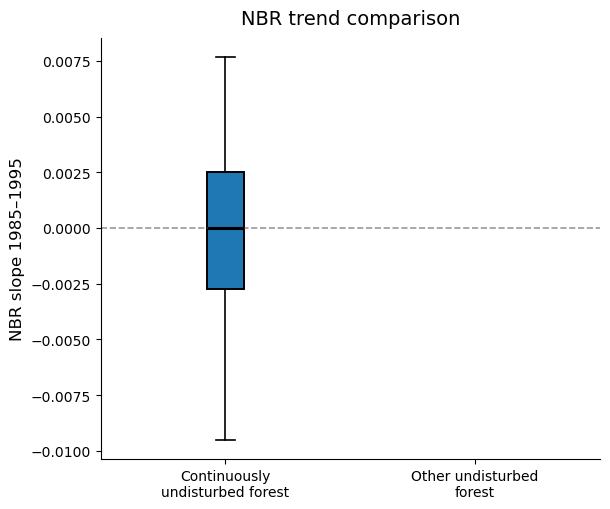

In [9]:
# ------------------------------------------------------------
# Plot: NBR trend comparison
# ------------------------------------------------------------
if df_nbr is not None:
    g1 = df_nbr[df_nbr["oldgrowth"] == 1].copy()
    g2 = df_nbr[(df_nbr["oldgrowth"] != 1) & (df_nbr["undisturbed"] == 1)].copy()

    plot_df = pd.concat([
        g1.assign(group="Continuously undisturbed forest"),
        g2.assign(group="Other undisturbed forest"),
    ], ignore_index=True)

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    ax.boxplot(
        [
            plot_df.loc[plot_df["group"] == "Continuously undisturbed forest", "slope"].dropna(),
            plot_df.loc[plot_df["group"] == "Other undisturbed forest", "slope"].dropna(),
        ],
        tick_labels=["Continuously\nundisturbed forest", "Other undisturbed\nforest"],
        showfliers=False,
        patch_artist=True,
        medianprops=dict(linewidth=2.2, color="black"),
        boxprops=dict(linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    ax.axhline(0, linestyle="--", linewidth=1.2, color="grey", alpha=0.8)
    ax.set_ylabel("NBR slope 1985–1995", fontsize=12)
    ax.set_title("NBR trend comparison", fontsize=14, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    save_fig(fig, fig_dir / "nbr_trend_boxplot")
    plt.show()
else:
    print("Skipped: df_nbr is missing.")


## 4. Tree genus composition and country summaries


Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.svg


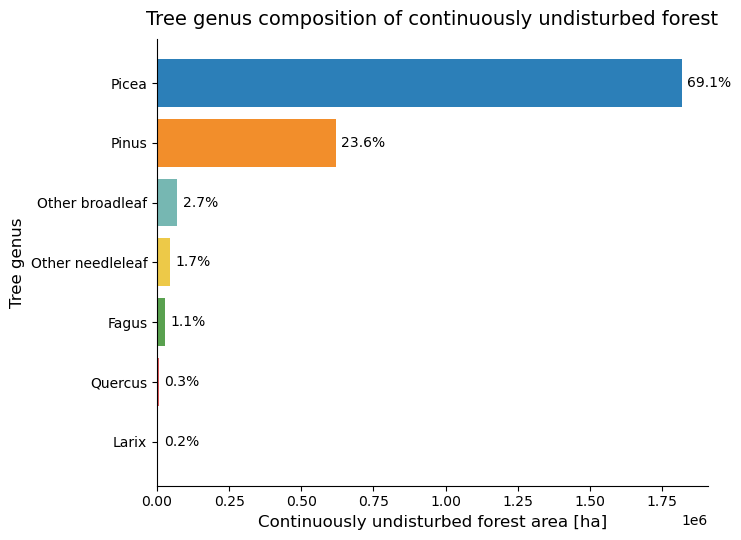

In [10]:
# ------------------------------------------------------------
# Plot: genus composition of continuously undisturbed forest
# ------------------------------------------------------------
if df_counts is not None:
    plot_df = df_counts[df_counts["genus"] != "No trees"].copy()
    plot_df = plot_df.sort_values("area_ha", ascending=True)
    plot_df["color"] = plot_df["genus"].map(genus_colors).fillna("#BDBDBD")

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.barh(plot_df["genus"], plot_df["area_ha"], color=plot_df["color"], edgecolor="none")
    ax.set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
    ax.set_ylabel("Tree genus", fontsize=12)
    ax.set_title(f"Tree genus composition of {forest_label}", fontsize=14, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    xmax = plot_df["area_ha"].max()
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["area_ha"] + xmax * 0.01, i, f'{row["percent"]:.1f}%', va="center", fontsize=10)

    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_genus_barplot")
    plt.show()
else:
    print("Skipped: df_counts is missing.")


Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.svg


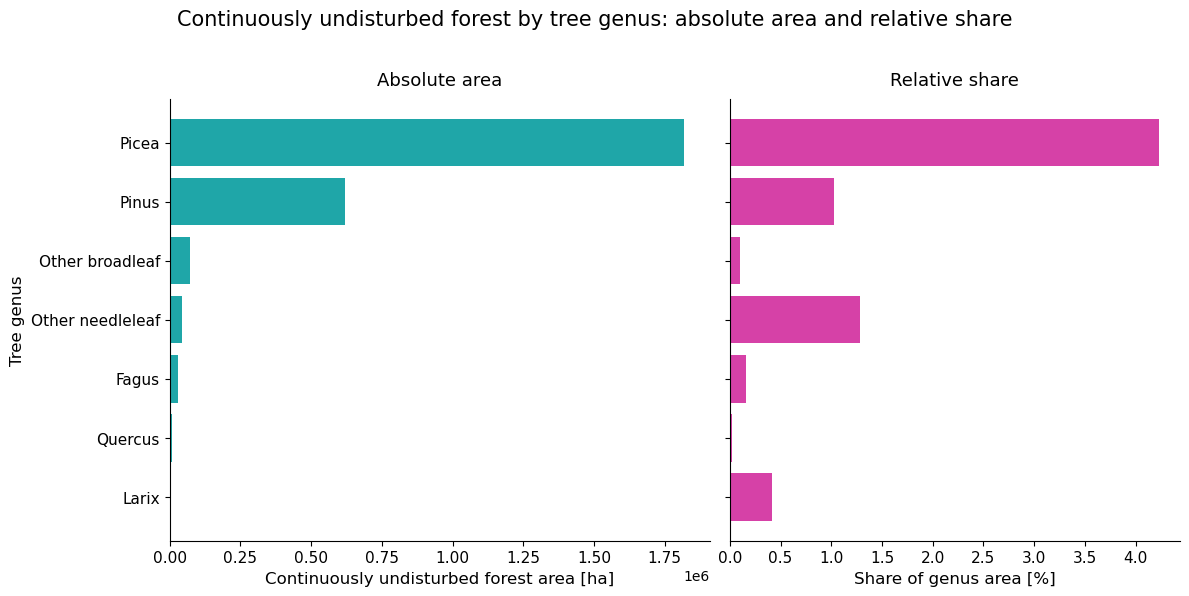

In [11]:
# ------------------------------------------------------------
# Plot: absolute area and relative share by genus
# ------------------------------------------------------------
if df_genus_share is not None:
    plot_df = df_genus_share.sort_values("oldgrowth_area_ha", ascending=True).copy()

    fig, axes = plt.subplots(
        1, 2, figsize=(12, 5.8), sharey=True,
        gridspec_kw={"width_ratios": [1.2, 1]},
    )
    axes[0].barh(plot_df["genus"], plot_df["oldgrowth_area_ha"], color="#1FA6A8")
    axes[0].set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
    axes[0].set_ylabel("Tree genus", fontsize=12)
    axes[0].set_title("Absolute area", fontsize=13, pad=10)

    axes[1].barh(plot_df["genus"], plot_df["oldgrowth_share_percent"], color="#D641A7")
    axes[1].set_xlabel("Share of genus area [%]", fontsize=12)
    axes[1].set_title("Relative share", fontsize=13, pad=10)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=11)

    fig.suptitle(f"{forest_label_cap} by tree genus: absolute area and relative share", fontsize=15, y=1.02)
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_absolute_and_relative_by_genus")
    plt.show()
else:
    print("Skipped: df_genus_share is missing.")


Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_barplot_matched_colors.svg


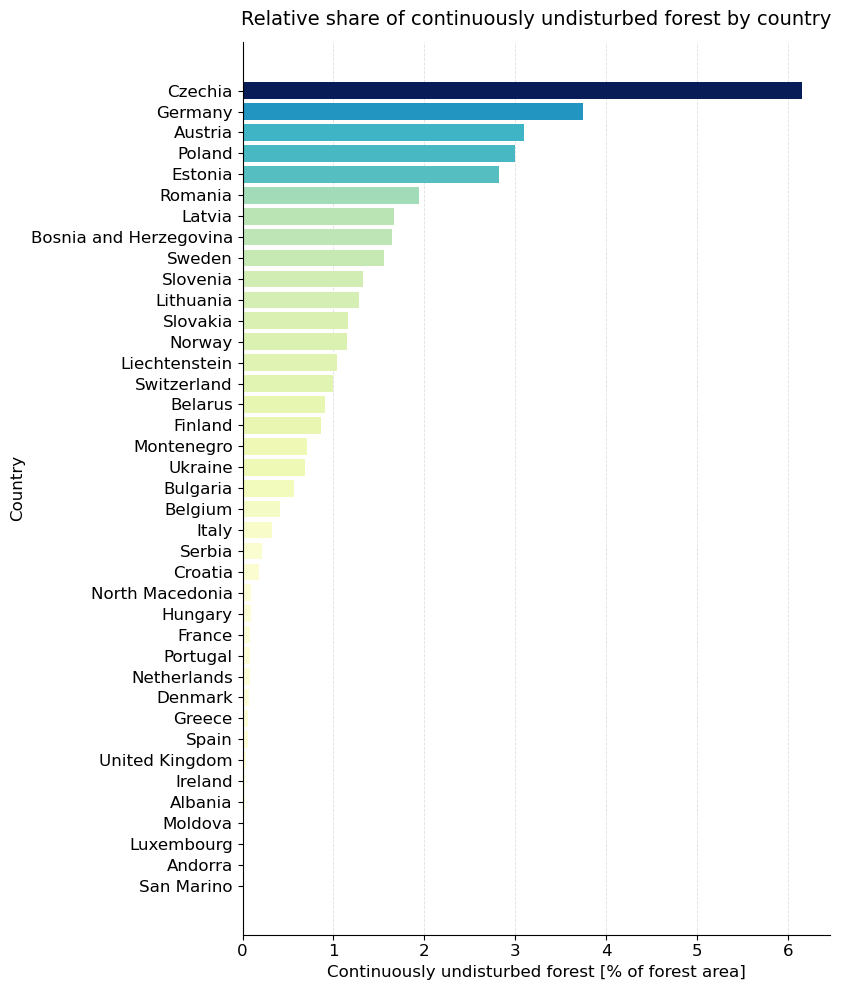

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_share_of_forest_by_country_map_matched_colors.svg


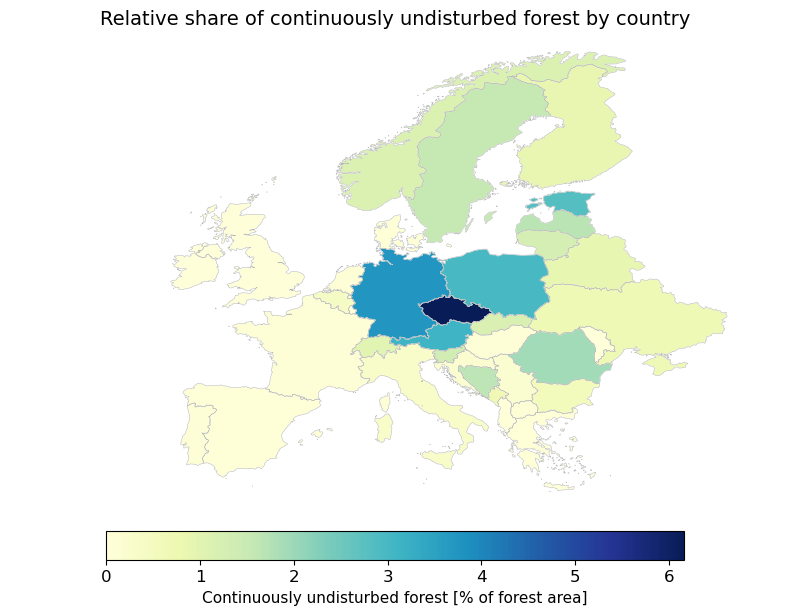

In [12]:
# ------------------------------------------------------------
# Plot: country share barplot and map
# ------------------------------------------------------------
if df_country_share is not None:
    cmap = plt.get_cmap("YlGnBu")
    vmin = 0
    vmax = df_country_share["oldgrowth_share_percent"].max()
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    country_bar = df_country_share.sort_values("oldgrowth_share_percent", ascending=True).copy()
    country_bar["plot_color"] = country_bar["oldgrowth_share_percent"].apply(lambda x: cmap(norm(x)))

    fig, ax = plt.subplots(figsize=(8.5, 10))
    ax.barh(country_bar["country"], country_bar["oldgrowth_share_percent"], color=country_bar["plot_color"])
    ax.set_xlabel(f"{forest_label_cap} [% of forest area]", fontsize=12)
    ax.set_ylabel("Country", fontsize=12)
    ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_share_of_forest_by_country_barplot_matched_colors")
    plt.show()

    with rasterio.open(old_growth_fp) as src:
        countries_map = load_europe_countries(target_crs=src.crs, clip_mainland=False)

    countries_map = countries_map.merge(
        country_bar[["country", "oldgrowth_share_percent", "plot_color"]],
        on="country", how="left",
    )
    countries_map["oldgrowth_share_percent"] = countries_map["oldgrowth_share_percent"].fillna(0)
    countries_map["plot_color"] = countries_map["plot_color"].fillna("#eeeeee")
    countries_map = countries_map.to_crs(4326)

    fig, ax = plt.subplots(figsize=(8, 8))
    countries_map.plot(color=countries_map["plot_color"], linewidth=0.5, edgecolor="white", ax=ax)
    countries_map.boundary.plot(ax=ax, color="0.7", linewidth=0.35)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.75, fraction=0.045, pad=0.04)
    cbar.set_label(f"{forest_label_cap} [% of forest area]", fontsize=11)
    cbar.ax.tick_params(labelsize=12)

    ax.set_xlim(-25, 45)
    ax.set_ylim(34, 72)
    ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
    ax.set_axis_off()
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_share_of_forest_by_country_map_matched_colors")
    plt.show()
else:
    print("Skipped: df_country_share is missing.")


## 5. Hexagon maps


Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.svg


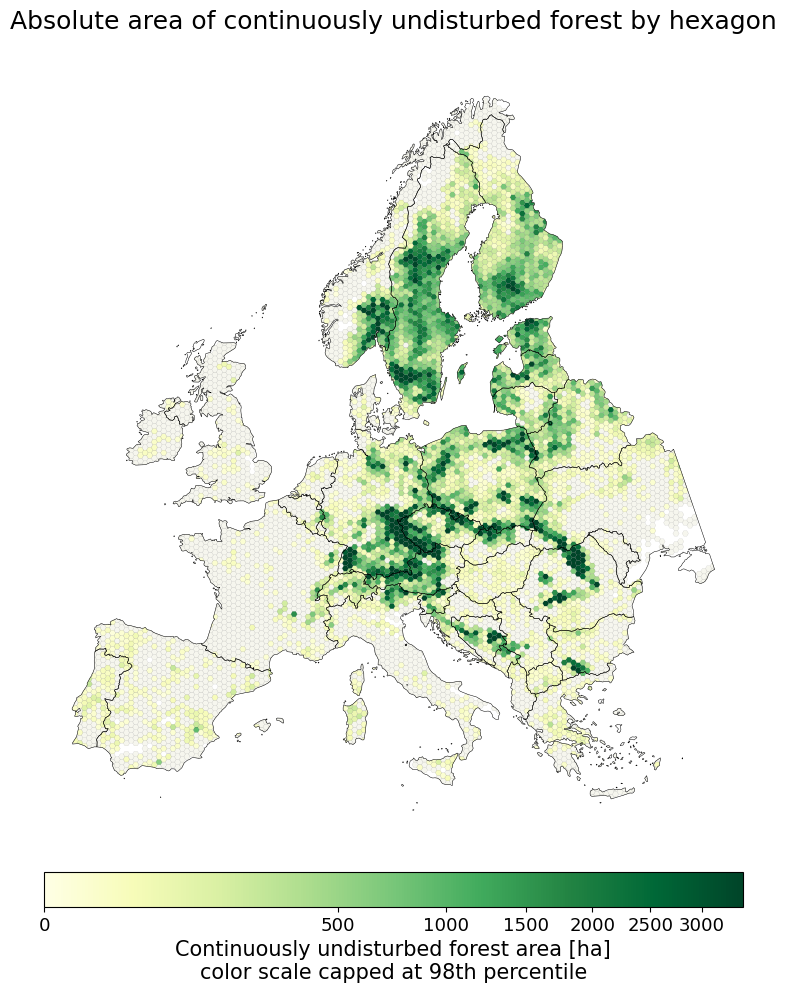

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.svg


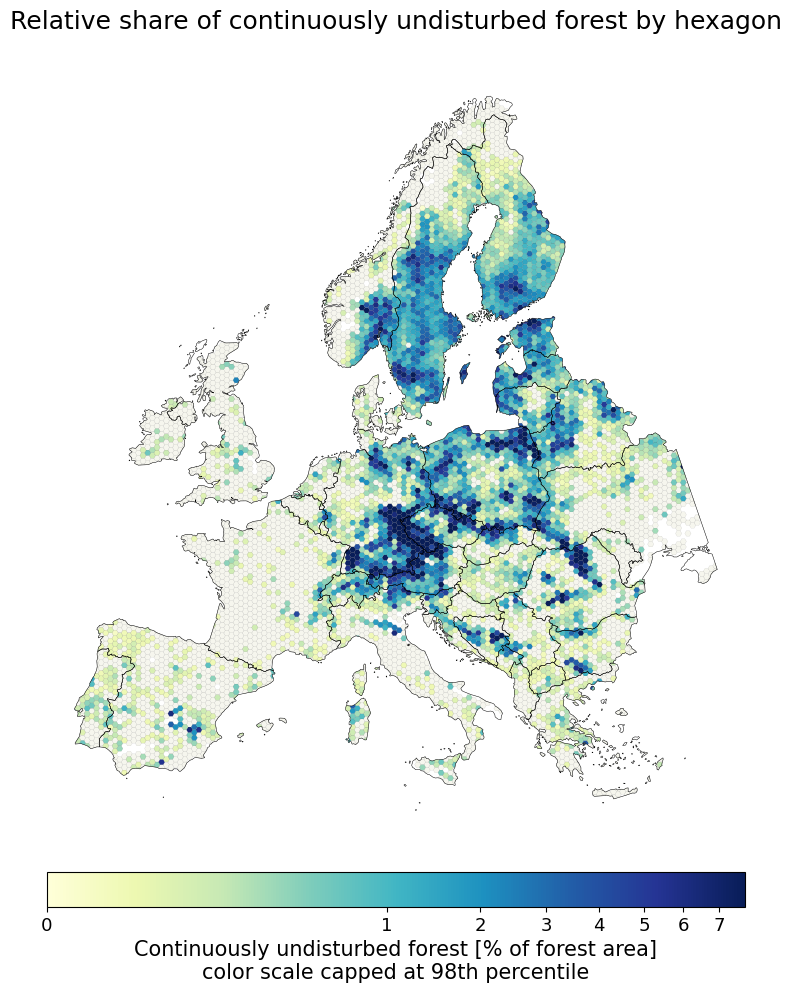

In [13]:
# ------------------------------------------------------------
# Plot: absolute and relative hexagon maps
# ------------------------------------------------------------
if hexes_plot is not None:
    if countries_eur is None:
        with rasterio.open(old_growth_fp) as src:
            countries_eur = load_europe_countries(target_crs=src.crs, clip_mainland=True)

    abs_vmin = 0
    abs_vmax = np.nanpercentile(hexes_plot["oldgrowth_area_ha"], 98)
    abs_norm = mpl.colors.PowerNorm(gamma=0.45, vmin=abs_vmin, vmax=abs_vmax)
    abs_cmap = plt.get_cmap("YlGn")

    rel_vmin = 0
    rel_vmax = np.nanpercentile(hexes_plot["oldgrowth_share_percent"], 98)
    rel_norm = mpl.colors.PowerNorm(gamma=0.35, vmin=rel_vmin, vmax=rel_vmax)
    rel_cmap = plt.get_cmap("YlGnBu")

    hexes_plot = hexes_plot.copy()
    hexes_plot["oldgrowth_area_ha_plot"] = hexes_plot["oldgrowth_area_ha"].clip(upper=abs_vmax)
    hexes_plot["oldgrowth_share_percent_plot"] = hexes_plot["oldgrowth_share_percent"].clip(upper=rel_vmax)

    title_size = 18
    legend_label_size = 15
    legend_tick_size = 13

    # Absolute area
    fig, ax = plt.subplots(figsize=(10, 10))
    hexes_zero_abs = hexes_plot[(hexes_plot["oldgrowth_area_ha"].isna()) | (hexes_plot["oldgrowth_area_ha"] <= 0)].copy()
    hexes_pos_abs = hexes_plot[(hexes_plot["oldgrowth_area_ha"].notna()) & (hexes_plot["oldgrowth_area_ha"] > 0)].copy()
    if len(hexes_zero_abs) > 0:
        hexes_zero_abs.plot(color="#f6f6ee", linewidth=0.05, edgecolor="0.3", ax=ax, zorder=1)
    hexes_pos_abs.plot(
        column="oldgrowth_area_ha_plot", cmap=abs_cmap, norm=abs_norm,
        linewidth=0.05, edgecolor="0.1", ax=ax, zorder=2,
    )
    countries_eur.boundary.plot(ax=ax, color="black", linewidth=0.35, zorder=3)
    sm_abs = mpl.cm.ScalarMappable(cmap=abs_cmap, norm=abs_norm)
    sm_abs.set_array([])
    cbar = fig.colorbar(sm_abs, ax=ax, orientation="horizontal", shrink=0.72, fraction=0.045, pad=0.03)
    cbar.set_label(f"{forest_label_cap} area [ha]\ncolor scale capped at 98th percentile", fontsize=legend_label_size)
    cbar.ax.tick_params(labelsize=legend_tick_size)
    ax.set_title(f"Absolute area of {forest_label} by hexagon", fontsize=title_size, pad=12)
    ax.set_axis_off()
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_absolute_area_by_small_clipped_hexagon_map")
    plt.show()

    # Relative share
    fig, ax = plt.subplots(figsize=(10, 10))
    hexes_zero_rel = hexes_plot[(hexes_plot["oldgrowth_share_percent"].isna()) | (hexes_plot["oldgrowth_share_percent"] <= 0)].copy()
    hexes_pos_rel = hexes_plot[(hexes_plot["oldgrowth_share_percent"].notna()) & (hexes_plot["oldgrowth_share_percent"] > 0)].copy()
    if len(hexes_zero_rel) > 0:
        hexes_zero_rel.plot(color="#f6f6ee", linewidth=0.05, edgecolor="0.3", ax=ax, zorder=1)
    hexes_pos_rel.plot(
        column="oldgrowth_share_percent_plot", cmap=rel_cmap, norm=rel_norm,
        linewidth=0.05, edgecolor="0.1", ax=ax, zorder=2,
    )
    countries_eur.boundary.plot(ax=ax, color="black", linewidth=0.35, zorder=3)
    sm_rel = mpl.cm.ScalarMappable(cmap=rel_cmap, norm=rel_norm)
    sm_rel.set_array([])
    cbar = fig.colorbar(sm_rel, ax=ax, orientation="horizontal", shrink=0.72, fraction=0.045, pad=0.03)
    cbar.set_label(f"{forest_label_cap} [% of forest area]\ncolor scale capped at 98th percentile", fontsize=legend_label_size)
    cbar.ax.tick_params(labelsize=legend_tick_size)
    ax.set_title(f"Relative share of {forest_label} by hexagon", fontsize=title_size, pad=12)
    ax.set_axis_off()
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_relative_share_by_small_clipped_hexagon_map")
    plt.show()
else:
    print("Skipped: hexes_plot is missing.")


## 6. Country pie map and simple genus summary


In [ ]:
# ------------------------------------------------------------
# Plot: country pie map of genus composition
# ------------------------------------------------------------
if df_gc is not None:
    top_n_genera = 5
    min_size = 0.2
    max_size = 0.5

    plot_gc = df_gc.copy()
    plot_gc["country"] = plot_gc["country"].astype(str).str.strip()
    plot_gc["genus"] = plot_gc["genus"].astype(str).str.strip()
    plot_gc = plot_gc[plot_gc["genus"] != "No trees"].copy()
    if exclude_russia:
        plot_gc = plot_gc[plot_gc["country"] != "Russian Federation"].copy()

    top_genera = (
        plot_gc.groupby("genus")["area_ha"]
        .sum().sort_values(ascending=False)
        .head(top_n_genera).index.tolist()
    )
    plot_gc["genus_plot"] = np.where(plot_gc["genus"].isin(top_genera), plot_gc["genus"], "Other")

    df_country_genus = plot_gc.groupby(["country", "genus_plot"], as_index=False)["area_ha"].sum()
    df_country_total = (
        df_country_genus.groupby("country", as_index=False)["area_ha"]
        .sum().rename(columns={"area_ha": "total_oldgrowth_ha"})
    )

    pie_table = df_country_genus.pivot(index="country", columns="genus_plot", values="area_ha").fillna(0)
    genus_order = [g for g in top_genera if g in pie_table.columns]
    if "Other" in pie_table.columns:
        genus_order = genus_order + ["Other"]
    pie_table = pie_table[genus_order]

    countries_map = load_europe_countries(target_crs=None, clip_mainland=True).to_crs(4326)
    countries_map = countries_map.merge(df_country_total, on="country", how="left")
    countries_with_data = countries_map[countries_map["total_oldgrowth_ha"].notna()].copy()
    if len(countries_with_data) == 0:
        raise ValueError("No countries with matched data found.")

    points = countries_with_data.representative_point()
    countries_with_data["x"] = points.x
    countries_with_data["y"] = points.y

    vals_sqrt = np.sqrt(countries_with_data["total_oldgrowth_ha"].values.astype(float))
    vmin, vmax = vals_sqrt.min(), vals_sqrt.max()
    countries_with_data["pie_size"] = (
        (min_size + max_size) / 2 if vmax == vmin
        else min_size + ((vals_sqrt - vmin) / (vmax - vmin)) * (max_size - min_size)
    )

    offsets = {
        "Belgium": (-0.6, 0.15), "Netherlands": (0.6, 0.4), "Luxembourg": (0.35, -0.35),
        "Switzerland": (-0.7, -0.25), "Austria": (0.7, -0.25), "Czechia": (0.7, 0.2),
        "Slovakia": (0.8, 0.0), "Slovenia": (-0.3, -0.5), "Croatia": (0.7, -0.3),
        "Bosnia and Herzegovina": (0.55, -0.2), "Serbia": (0.6, -0.1), "Montenegro": (0.55, -0.45),
        "Kosovo": (0.55, -0.2), "Albania": (0.6, -0.2), "North Macedonia": (0.7, -0.05),
        "Moldova": (0.7, 0.0), "Portugal": (-0.5, -0.1), "Ireland": (-0.4, 0.0), "Denmark": (0.2, 0.4),
    }
    for country, (dx, dy) in offsets.items():
        idx = countries_with_data["country"] == country
        countries_with_data.loc[idx, "x"] += dx
        countries_with_data.loc[idx, "y"] += dy

    fig, ax = plt.subplots(figsize=(14, 10))
    countries_map.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.5, zorder=1)
    countries_map.boundary.plot(ax=ax, color="0.55", linewidth=0.35, zorder=2)

    for _, row in countries_with_data.iterrows():
        country = row["country"]
        if country not in pie_table.index:
            continue
        values = pie_table.loc[country, genus_order].values.astype(float)
        if values.sum() <= 0:
            continue
        axins = inset_axes(
            ax, width=row["pie_size"], height=row["pie_size"], loc="center",
            bbox_to_anchor=(row["x"], row["y"]), bbox_transform=ax.transData, borderpad=0,
        )
        axins.pie(
            values,
            colors=[genus_colors.get(g, "#cccccc") for g in genus_order],
            startangle=90, counterclock=False,
            wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
        )
        axins.set_aspect("equal")
        axins.set_axis_off()

    handles = [Patch(facecolor=genus_colors.get(g, "#cccccc"), edgecolor="none", label=g) for g in genus_order]
    ax.legend(handles=handles, title="Tree genus", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, facecolor="white", edgecolor="0.85", fontsize=12, title_fontsize=13)
    ax.set_xlim(-11, 35)
    ax.set_ylim(34, 72)
    ax.set_axis_off()
    ax.set_title(f"Tree genus composition of {forest_label} by country", fontsize=16, pad=12)
    plt.tight_layout()
    save_fig(fig, fig_dir / "old_growth_country_pie_map_fixed_allcountries")
    plt.show()
else:
    print("Skipped: df_gc is missing.")


## 7. Probability distributions by genus


In [ ]:
# ------------------------------------------------------------
# Ridge plot: density curves of continuity probability by genus
# with relative forest area share per genus
# ------------------------------------------------------------
if df_prob_genus is not None:
    df_plot = df_prob_genus.copy()
    df_plot = df_plot[
        df_plot["probability"].notna() &
        df_plot["genus"].notna() &
        (df_plot["probability"] >= 0) &
        (df_plot["probability"] <= 1) &
        (df_plot["genus"] != "No trees")
    ].copy()

    min_n = 50
    x_grid = np.linspace(0, 1, 500)
    ridge_height = 0.85

    genus_area_share = (
        df_plot["genus"].value_counts(normalize=True).mul(100).round(1).to_dict()
    )
    order = (
        df_plot.groupby("genus")["probability"].median().sort_values(ascending=True).index.tolist()
    )
    order = [g for g in order if (df_plot["genus"] == g).sum() >= min_n]

    fig_height = max(4.5, 0.55 * len(order) + 1.2)
    fig, ax = plt.subplots(figsize=(8, fig_height))

    for y, genus in enumerate(order):
        vals = df_plot.loc[df_plot["genus"] == genus, "probability"].dropna().values
        if len(vals) < min_n:
            continue
        kde = gaussian_kde(vals)
        dens = kde(x_grid)
        dens = dens / dens.max() * ridge_height
        color = genus_colors.get(genus, "#BDBDBD")
        ax.fill_between(x_grid, y, y + dens, color=color, alpha=0.70, linewidth=0)
        ax.plot(x_grid, y + dens, color=color, linewidth=1.8)
        ax.axhline(y, color="0.85", linewidth=0.6, zorder=0)

    labels = [f"{g} ({genus_area_share.get(g, np.nan):.1f}%)" for g in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Continuity probability", fontsize=12)
    ax.set_ylabel("Tree genus (% of sampled forest area)", fontsize=12)
    ax.set_title("Continuity probability distributions by tree genus", fontsize=14, pad=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.35)
    plt.tight_layout()
    save_fig(fig, prob_genus_fig_dir / "ridge_probability_by_genus_named_area_share")
    plt.show()
else:
    print("Skipped: df_prob_genus is missing.")


In [ ]:
# ------------------------------------------------------------
# Summary table: probability by genus
# ------------------------------------------------------------
if df_prob_genus is not None:
    summary = (
        df_prob_genus
        .groupby("genus")
        .agg(
            n=("probability", "size"),
            mean_prob=("probability", "mean"),
            median_prob=("probability", "median"),
            q10=("probability", lambda x: x.quantile(0.10)),
            q90=("probability", lambda x: x.quantile(0.90)),
            share_gt_075=("probability", lambda x: (x > 0.75).mean()),
            share_gt_090=("probability", lambda x: (x > 0.90).mean()),
            share_gt_095=("probability", lambda x: (x > 0.95).mean()),
        )
        .reset_index()
        .sort_values("median_prob", ascending=False)
    )
    summary.to_csv(prob_genus_summary_csv, index=False)
    print("Written:", prob_genus_summary_csv)
    display(summary)
else:
    print("Skipped: df_prob_genus is missing.")


## 8. Forest-age preprocessing and apples-to-apples map

This section uses a prepared forest-age raster instead of repeatedly opening the global NetCDF. The prepared raster contains only Europe, the 2020 forest-age layer, and the first ensemble member. If it is missing, it is only created when `RUN_EXPENSIVE_IF_MISSING = True`.

The hexagon comparison uses the same denominator for both products: total forest area from the 30 m forest mask. The forest-age threshold is `2020 - 1965 = 55` years, i.e. stands old enough in 2020 to have potentially existed before 1965.


In [14]:
# ------------------------------------------------------------
# Prepare/load forest-age Europe raster and forest-age hex comparison
# ------------------------------------------------------------
print("Forest-age threshold:", age_threshold, "years")
print("Target forest-age raster:", forest_age_2020_member1_europe_fp)

if forest_age_2020_member1_europe_fp.exists():
    print("Using existing prepared forest-age raster:", forest_age_2020_member1_europe_fp)
elif RUN_EXPENSIVE_IF_MISSING:
    forest_age_2020_member1_europe_fp = extract_forest_age_2020_member1_europe()
else:
    print(
        "Prepared forest-age raster is missing. "
        "Set RUN_EXPENSIVE_IF_MISSING = True once to extract Europe/member 1 from the global NetCDF."
    )

hex_compare = globals().get("hex_compare", None)

# Prefer the exact output generated by this notebook version.
if hex_compare is None and hex_compare_gpkg.exists():
    hex_compare = gpd.read_file(hex_compare_gpkg, layer="hexes")
    print("Loaded exact forest-age comparison product:", hex_compare_gpkg)

# Fall back to scanned geodata if the exact output name differs.
if hex_compare is None:
    for name, gdf in loaded_geodata.items():
        cols = set(gdf.columns)
        if any(c.startswith("forest_age_ge_") and c.endswith("_share_percent") for c in cols):
            hex_compare = gdf.copy()
            print(f"Using forest-age geodata from loaded_geodata['{name}']")
            break

# Compute only if explicitly enabled.
if hex_compare is None and RUN_EXPENSIVE_IF_MISSING:
    if not forest_age_2020_member1_europe_fp.exists():
        forest_age_2020_member1_europe_fp = extract_forest_age_2020_member1_europe()
    hex_compare = compute_hex_forest_age_comparison(
        forest_age_fp=forest_age_2020_member1_europe_fp,
        out_gpkg=hex_compare_gpkg,
        out_csv=hex_compare_csv,
    )

if hex_compare is None:
    print("No forest-age hex comparison product available. Forest-age maps will be skipped.")
else:
    print("hex_compare available:", hex_compare.shape)
    display(hex_compare.head())


Forest-age threshold: 55 years
Target forest-age raster: /mnt/eo/EO4Backcasting/_data_aligned/GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif
Prepared forest-age raster is missing. Set RUN_EXPENSIVE_IF_MISSING = True once to extract Europe/member 1 from the global NetCDF.
Using forest-age geodata from loaded_geodata['hexagon_forest_age_ge_55_member0_share']
hex_compare available: (7553, 10)


,hex_id,forest_pixels,oldgrowth_pixels,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,forest_age_valid_pixels,forest_age_ge_55_pixels,forest_age_ge_55_share_percent,geometry
0,4,34169.0,69.0,3075.21,6.21,0.201937,None,NaN,None,"MULTIPOLYGON (((2987951.141 1627568.992, 30054..."
1,7,52732.0,131.0,4745.88,11.79,0.248426,None,NaN,None,"MULTIPOLYGON (((3066701.141 1642724.437, 30842..."
2,8,36758.0,0.0,3308.22,0.00,0.000000,None,NaN,None,"MULTIPOLYGON (((3005451.141 1627568.992, 30142..."
3,9,64124.0,0.0,5771.16,0.00,0.000000,None,NaN,None,"MULTIPOLYGON (((3110451.141 1627568.992, 31192..."
4,10,145163.0,0.0,13064.67,0.00,0.000000,None,NaN,None,"MULTIPOLYGON (((3162951.141 1627568.992, 31454..."


In [16]:
import xarray as xr
import rioxarray
import netCDF4
import dask

print("xarray:", xr.__version__)
print("rioxarray works")

xarray: 2026.4.0
rioxarray works


In [17]:
# ------------------------------------------------------------
# Create Europe-only forest age raster:
# 2020, first member, Europe bounding box
# ------------------------------------------------------------

from pathlib import Path
import xarray as xr
import rioxarray  # important for .rio accessor
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

forest_age_nc = Path(
    "/mnt/eo/EO4Backcasting/_data/forest_age/"
    "GAMIv2-1_2010-2020_100m.nc"
)

out_dir = Path("/mnt/eo/EO4Backcasting/_data_aligned")
out_dir.mkdir(parents=True, exist_ok=True)

forest_age_fp = out_dir / "GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif"

# ------------------------------------------------------------
# Europe bounding box in lon/lat
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = -11, 34, 35, 72

# ------------------------------------------------------------
# Check input
# ------------------------------------------------------------

if not forest_age_nc.exists():
    raise FileNotFoundError(f"Forest age NetCDF not found: {forest_age_nc}")

print("Input NetCDF:", forest_age_nc)
print("Output GeoTIFF:", forest_age_fp)

# ------------------------------------------------------------
# Open global NetCDF
# ------------------------------------------------------------

ds = xr.open_dataset(
    forest_age_nc,
    chunks={"latitude": 1000, "longitude": 1000}
)

print(ds)

age = ds["forest_age"]

# ------------------------------------------------------------
# Detect dimension names
# ------------------------------------------------------------

lat_name = "latitude" if "latitude" in age.dims else "lat"
lon_name = "longitude" if "longitude" in age.dims else "lon"

time_name = "time" if "time" in age.dims else None

member_dim = None
for cand in ["members", "member", "ensemble", "ens"]:
    if cand in age.dims:
        member_dim = cand
        break

print("lat_name:", lat_name)
print("lon_name:", lon_name)
print("time_name:", time_name)
print("member_dim:", member_dim)

# ------------------------------------------------------------
# Select year 2020 and first member
# ------------------------------------------------------------

age_sel = age

if time_name is not None:
    age_sel = age_sel.sel({time_name: "2020-01-01"}, method="nearest")

if member_dim is not None:
    age_sel = age_sel.isel({member_dim: 0})

age_sel = age_sel.squeeze(drop=True)

print(age_sel)

# ------------------------------------------------------------
# Subset to Europe
# ------------------------------------------------------------

lat_values = age_sel[lat_name].values

if lat_values[0] > lat_values[-1]:
    # descending latitude
    age_eur = age_sel.sel({
        lon_name: slice(xmin, xmax),
        lat_name: slice(ymax, ymin)
    })
else:
    # ascending latitude
    age_eur = age_sel.sel({
        lon_name: slice(xmin, xmax),
        lat_name: slice(ymin, ymax)
    })

# ------------------------------------------------------------
# Prepare spatial metadata
# ------------------------------------------------------------

age_eur = age_eur.astype("float32")

age_eur = (
    age_eur
    .rio.set_spatial_dims(x_dim=lon_name, y_dim=lat_name)
    .rio.write_crs("EPSG:4326")
)

# Keep NaN as nodata-compatible output
age_eur = age_eur.rio.write_nodata(-9999, encoded=True)

# ------------------------------------------------------------
# Save GeoTIFF
# ------------------------------------------------------------

age_eur.rio.to_raster(
    forest_age_fp,
    dtype="float32",
    compress="deflate",
    tiled=True,
    BIGTIFF="YES"
)

print("Written:", forest_age_fp)

Input NetCDF: /mnt/eo/EO4Backcasting/_data/forest_age/GAMIv2-1_2010-2020_100m.nc
Output GeoTIFF: /mnt/eo/EO4Backcasting/_data_aligned/GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif
<xarray.Dataset> Size: 7TB
Dimensions:     (members: 20, latitude: 202500, longitude: 405000, time: 2)
Coordinates:
  * members     (members) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * latitude    (latitude) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0
  * longitude   (longitude) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0
  * time        (time) datetime64[ns] 16B 2010-01-01 2020-01-01
Data variables:
    forest_age  (members, latitude, longitude, time) int16 7TB dask.array<chunksize=(1, 1000, 1000, 1), meta=np.ndarray>
    crs         int64 8B ...
Attributes:
    product_name:   Global Age Mapping Integration (GAMI) v2.0
    version:        v2.1
    institution:    Helmholtz Center Potsdam GFZ German Research Centre for G...
    institute_id:   GFZ-Potsdam and MPI-BG

/tmp/ipykernel_989905/628394417.py:45: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_989905/628394417.py:45: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


<xarray.DataArray 'forest_age' (latitude: 202500, longitude: 405000)> Size: 164GB
dask.array<getitem, shape=(202500, 405000), dtype=int16, chunksize=(1000, 1000), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0
  * longitude  (longitude) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0
    members    int64 8B 0
    time       datetime64[ns] 8B 2020-01-01
Attributes:
    grid_mapping:  crs
    long_name:     'Forest age using a fusion machine learning and Landsat-ba...
    units:         years
    valid_max:     300
    valid_min:     1.0
Written: /mnt/eo/EO4Backcasting/_data_aligned/GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif


In [18]:
import rasterio
import numpy as np

with rasterio.open(forest_age_fp) as src:
    print("Path:", src.name)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Shape:", src.height, src.width)
    print("Nodata:", src.nodata)

    arr = src.read(1, masked=True)

    print("Valid pixels:", arr.count())
    print("Min:", float(arr.min()))
    print("Max:", float(arr.max()))
    print("Mean:", float(arr.mean()))

Path: /mnt/eo/EO4Backcasting/_data_aligned/GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-11.000000000000004, bottom=34.0, right=35.0, top=72.0)
Shape: 42750 51750
Nodata: -9999.0
Valid pixels: 421393781
Min: 0.0
Max: 300.0
Mean: 97.64489056852028


In [19]:
# ------------------------------------------------------------
# Add forest-age-based share to existing hexagon GPKG
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
from shapely.geometry import box
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

analysis_cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")

hex_fp = analysis_cache_dir / "continuously_undisturbed_by_small_clipped_hexagon.gpkg"

forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")

old_growth_fp = Path(
    "/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/"
    "global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
)

forest_age_fp = Path(
    "/mnt/eo/EO4Backcasting/_data_aligned/"
    "GAMIv2_1_forest_age_2020_member1_europe_100m_epsg4326.tif"
)

out_fp = analysis_cache_dir / "continuously_undisturbed_by_small_clipped_hexagon_with_forest_age.gpkg"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

age_threshold = 55       # 2020 - 1965
forest_value = 1
pixel_area_ha = 0.09     # 30 m pixel
overwrite = True

# ------------------------------------------------------------
# Load existing hexagons
# ------------------------------------------------------------

hex_compare = gpd.read_file(hex_fp).copy()

print("Loaded:", hex_fp)
print("CRS:", hex_compare.crs)
print("N hexagons:", len(hex_compare))
print("Columns:", list(hex_compare.columns))

required_cols = ["hex_id", "forest_area_ha", "geometry"]
missing = [c for c in required_cols if c not in hex_compare.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

hex_compare["hex_id"] = hex_compare["hex_id"].astype(int)
hex_compare["forest_area_ha"] = pd.to_numeric(
    hex_compare["forest_area_ha"],
    errors="coerce"
)

hex_compare = hex_compare[
    hex_compare["forest_area_ha"].notna() &
    (hex_compare["forest_area_ha"] > 0)
].copy()

print("Hexagons with forest area > 0:", len(hex_compare))

# ------------------------------------------------------------
# Prepare counters
# ------------------------------------------------------------

max_hex_id = int(hex_compare["hex_id"].max())

forest_age_valid_pixels = np.zeros(max_hex_id + 1, dtype=np.int64)
forest_age_ge_55_pixels = np.zeros(max_hex_id + 1, dtype=np.int64)

# ------------------------------------------------------------
# Aggregate forest age to existing hexagons
# ------------------------------------------------------------

with rasterio.open(old_growth_fp) as cont_src, \
     rasterio.open(forest_mask_fp) as forest_src, \
     rasterio.open(forest_age_fp) as age_src:

    print("\nTarget raster CRS:", cont_src.crs)
    print("Target raster bounds:", cont_src.bounds)

    print("\nForest age CRS:", age_src.crs)
    print("Forest age bounds:", age_src.bounds)

    hexes = hex_compare[["hex_id", "geometry"]].copy().to_crs(cont_src.crs)
    sindex = hexes.sindex

    forest_vrt = WarpedVRT(
        forest_src,
        crs=cont_src.crs,
        transform=cont_src.transform,
        width=cont_src.width,
        height=cont_src.height,
        resampling=Resampling.nearest
    )

    age_vrt = WarpedVRT(
        age_src,
        crs=cont_src.crs,
        transform=cont_src.transform,
        width=cont_src.width,
        height=cont_src.height,
        resampling=Resampling.nearest,
        src_nodata=age_src.nodata,
        nodata=-9999
    )

    windows = list(cont_src.block_windows(1))

    for _, window in tqdm(windows, desc="Aggregating forest age by hexagon"):

        wb = window_bounds(window, cont_src.transform)

        cand_idx = list(sindex.intersection(wb))
        if len(cand_idx) == 0:
            continue

        cand = hexes.iloc[cand_idx].copy()

        if len(cand) == 0:
            continue

        win_transform = window_transform(window, cont_src.transform)
        out_shape = (int(window.height), int(window.width))

        hex_id_arr = rasterize(
            [(geom, int(hid)) for geom, hid in zip(cand.geometry, cand["hex_id"])],
            out_shape=out_shape,
            transform=win_transform,
            fill=0,
            dtype="int32",
            all_touched=False
        )

        if hex_id_arr.max() == 0:
            continue

        forest = forest_vrt.read(1, window=window)
        age = age_vrt.read(1, window=window).astype("float32")

        forest_mask = (
            (forest == forest_value) &
            (hex_id_arr > 0)
        )

        if not np.any(forest_mask):
            continue

        age_valid_mask = (
            forest_mask &
            np.isfinite(age) &
            (age != -9999) &
            (age >= 0) &
            (age <= 140)
        )

        if np.any(age_valid_mask):
            forest_age_valid_pixels += np.bincount(
                hex_id_arr[age_valid_mask],
                minlength=max_hex_id + 1
            )

        age_ge_mask = age_valid_mask & (age >= age_threshold)

        if np.any(age_ge_mask):
            forest_age_ge_55_pixels += np.bincount(
                hex_id_arr[age_ge_mask],
                minlength=max_hex_id + 1
            )

    forest_vrt.close()
    age_vrt.close()

# ------------------------------------------------------------
# Add new columns
# ------------------------------------------------------------

ids = hex_compare["hex_id"].values.astype(int)

hex_compare["forest_age_valid_pixels"] = forest_age_valid_pixels[ids]
hex_compare[f"forest_age_ge_{age_threshold}_pixels"] = forest_age_ge_55_pixels[ids]

hex_compare["forest_age_valid_area_ha"] = (
    hex_compare["forest_age_valid_pixels"] * pixel_area_ha
)

hex_compare[f"forest_age_ge_{age_threshold}_area_ha"] = (
    hex_compare[f"forest_age_ge_{age_threshold}_pixels"] * pixel_area_ha
)

hex_compare[f"forest_age_ge_{age_threshold}_share_percent"] = np.where(
    hex_compare["forest_area_ha"] > 0,
    hex_compare[f"forest_age_ge_{age_threshold}_area_ha"] /
    hex_compare["forest_area_ha"] * 100,
    np.nan
)

hex_compare["forest_age_valid_coverage_percent"] = np.where(
    hex_compare["forest_area_ha"] > 0,
    hex_compare["forest_age_valid_area_ha"] /
    hex_compare["forest_area_ha"] * 100,
    np.nan
)

# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

age_share_col = f"forest_age_ge_{age_threshold}_share_percent"

cols_check = [
    "forest_area_ha",
    "oldgrowth_area_ha",
    "oldgrowth_share_percent",
    "forest_age_valid_area_ha",
    f"forest_age_ge_{age_threshold}_area_ha",
    age_share_col,
    "forest_age_valid_coverage_percent"
]

existing_cols_check = [c for c in cols_check if c in hex_compare.columns]

display(hex_compare[existing_cols_check].describe())

print("Valid forest-age share hexagons:", hex_compare[age_share_col].notna().sum())
print("Hexagons with age coverage > 0:", (hex_compare["forest_age_valid_pixels"] > 0).sum())

display(hex_compare[existing_cols_check].head())

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

if out_fp.exists() and overwrite:
    out_fp.unlink()

hex_compare.to_file(out_fp, driver="GPKG")

print("Saved:", out_fp)

Loaded: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_by_small_clipped_hexagon.gpkg
CRS: EPSG:3035
N hexagons: 7553
Columns: ['hex_id', 'forest_pixels', 'oldgrowth_pixels', 'forest_area_ha', 'oldgrowth_area_ha', 'oldgrowth_share_percent', 'geometry']
Hexagons with forest area > 0: 7553

Target raster CRS: EPSG:3035
Target raster bounds: BoundingBox(left=2612197.933345846, bottom=1365550.4228236396, right=6512197.933345846, top=5565550.42282364)

Forest age CRS: EPSG:4326
Forest age bounds: BoundingBox(left=-11.000000000000004, bottom=34.0, right=35.0, top=72.0)


Aggregating forest age by hexagon:   0%|          | 0/140000 [00:00<?, ?it/s]

,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,forest_age_valid_area_ha,forest_age_ge_55_area_ha,forest_age_ge_55_share_percent,forest_age_valid_coverage_percent
count,7553.000000,7553.000000,7553.000000,7553.000000,7553.000000,7553.000000,7553.000000
mean,28321.260830,354.652251,0.858823,18919.486579,14113.759796,46.870253,64.750798
std,20967.093835,1115.053067,2.357489,16078.926678,12945.971018,24.479918,26.039593
min,505.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9278.730000,0.000000,0.000000,4463.910000,2638.800000,27.947527,50.815786
50%,24667.560000,6.390000,0.027019,15322.950000,10789.650000,53.049978,75.008388
75%,44583.750000,168.390000,0.588980,30282.210000,23144.220000,66.533316,84.643970
max,75618.090000,25517.340000,42.330139,71654.850000,60666.120000,96.361505,97.214804


Valid forest-age share hexagons: 7553
Hexagons with age coverage > 0: 7523


,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,forest_age_valid_area_ha,forest_age_ge_55_area_ha,forest_age_ge_55_share_percent,forest_age_valid_coverage_percent
0,3075.21,6.21,0.201937,2380.68,1959.21,63.709795,77.415201
1,4745.88,11.79,0.248426,4086.72,4069.08,85.739210,86.110900
2,3308.22,0.00,0.000000,2894.04,2886.03,87.238152,87.480276
3,5771.16,0.00,0.000000,4620.87,4565.43,79.107666,80.068305
4,13064.67,0.00,0.000000,6181.02,5833.44,44.650496,47.310954


Saved: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_by_small_clipped_hexagon_with_forest_age.gpkg


In [21]:
from shapely.geometry import box
import geopandas as gpd

# ------------------------------------------------------------
# Remove overseas regions / keep European mainland extent only
# ------------------------------------------------------------

# Bounding box for Europe in lon/lat
# Adjust if needed, but this removes overseas territories.
europe_bbox_4326 = box(-11, 34, 35, 72)

bbox_gdf = gpd.GeoDataFrame(
    geometry=[europe_bbox_4326],
    crs="EPSG:4326"
)

# Transform bbox to map CRS
bbox_plot_crs = bbox_gdf.to_crs(hex_compare.crs)

# Clip hexagons
hex_compare = gpd.clip(
    hex_compare,
    bbox_plot_crs
).copy()

# Clip countries
countries_eur = gpd.clip(
    countries_eur,
    bbox_plot_crs
).copy()

# Remove empty geometries
hex_compare = hex_compare[
    hex_compare.geometry.notna() &
    ~hex_compare.geometry.is_empty
].copy()

countries_eur = countries_eur[
    countries_eur.geometry.notna() &
    ~countries_eur.geometry.is_empty
].copy()

print("Hexagons after Europe bbox clip:", len(hex_compare))
print("Country geometries after Europe bbox clip:", len(countries_eur))

Hexagons after Europe bbox clip: 7502
Country geometries after Europe bbox clip: 40


In [22]:
# ------------------------------------------------------------
# Load Europe country boundaries without overseas regions
# ------------------------------------------------------------

from shapely.geometry import box
import geopandas as gpd

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
    "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

countries_eur = gpd.read_file(country_gpkg_10m)
countries_eur["country"] = countries_eur[country_name_col].astype(str).str.strip()
countries_eur = countries_eur[countries_eur["country"].isin(european_countries)].copy()
countries_eur = countries_eur[countries_eur.geometry.notna() & ~countries_eur.geometry.is_empty].copy()
countries_eur["geometry"] = countries_eur.geometry.make_valid()

# First go to lon/lat, explode multipart geometries, and keep only Europe bbox
countries_eur = countries_eur.to_crs("EPSG:4326")
countries_eur = countries_eur.explode(index_parts=False).reset_index(drop=True)

europe_bbox = gpd.GeoDataFrame(
    geometry=[box(-11, 34, 35, 72)],
    crs="EPSG:4326"
)

countries_eur = gpd.clip(countries_eur, europe_bbox)

# Back to plot CRS
countries_eur = countries_eur.to_crs(hex_compare.crs)

countries_eur = countries_eur[
    countries_eur.geometry.notna() &
    ~countries_eur.geometry.is_empty
].copy()

print("Country geometries:", len(countries_eur))

Country geometries: 663


In [23]:
# ------------------------------------------------------------
# Clip hexagons to same European extent
# ------------------------------------------------------------

europe_bbox_plot = europe_bbox.to_crs(hex_compare.crs)

hex_compare = gpd.clip(hex_compare, europe_bbox_plot).copy()

hex_compare = hex_compare[
    hex_compare.geometry.notna() &
    ~hex_compare.geometry.is_empty
].copy()

print("Hexagons after clipping:", len(hex_compare))

Hexagons after clipping: 7502


Forest-age native vmax: 83.16261862231009


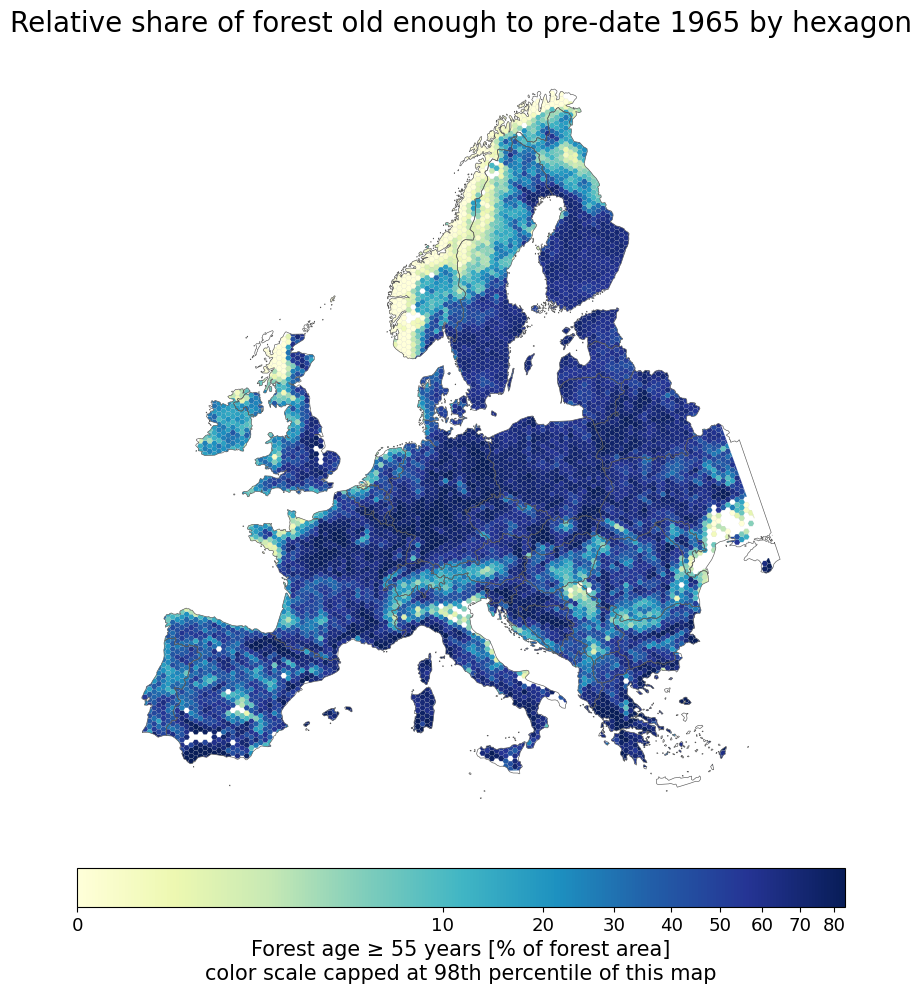

Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/map_relative_share_forest_age_ge_55_by_hexagon_native_scale.png
Saved: /mnt/eo/EO4Backcasting/_figures/forest_age_comparison/map_relative_share_forest_age_ge_55_by_hexagon_native_scale.svg


In [25]:
# ------------------------------------------------------------
# Native color scaling for forest-age map
# ------------------------------------------------------------

vmax_age = np.nanpercentile(hex_compare[age_share_col], 98)

print("Forest-age native vmax:", vmax_age)

norm_age = mpl.colors.PowerNorm(gamma=0.35, vmin=0, vmax=vmax_age)
cmap = plt.get_cmap("YlGnBu")


# ------------------------------------------------------------
# Single map: forest age >= 55 years with native value range
# ------------------------------------------------------------

plot_gdf = hex_compare.copy()
plot_gdf[f"{age_share_col}_plot"] = plot_gdf[age_share_col].clip(upper=vmax_age)

fig, ax = plt.subplots(figsize=(10, 10))

plot_gdf.plot(
    ax=ax,
    column=f"{age_share_col}_plot",
    cmap=cmap,
    norm=norm_age,
    linewidth=0.08,
    edgecolor="0.75",
    missing_kwds={
        "color": "white",
        "edgecolor": "0.85"
    }
)

countries_eur.boundary.plot(
    ax=ax,
    color="0.35",
    linewidth=0.45
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_age)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    shrink=0.80,
    fraction=0.045,
    pad=0.04
)

cbar.set_label(
    "Forest age ≥ 55 years [% of forest area]\n"
    "color scale capped at 98th percentile of this map",
    fontsize=15
)

cbar.ax.tick_params(labelsize=13)

ax.set_title(
    "Relative share of forest old enough to pre-date 1965 by hexagon",
    fontsize=20,
    pad=16
)

ax.set_axis_off()

plt.tight_layout()

out_png = fig_dir / "map_relative_share_forest_age_ge_55_by_hexagon_native_scale.png"
out_svg = fig_dir / "map_relative_share_forest_age_ge_55_by_hexagon_native_scale.svg"

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_png)
print("Saved:", out_svg)

## 9. Final object backup

This backup is small and helps you restart later without rebuilding Python objects. It does not replace the written CSV/GPKG products, which remain the primary cache.


In [ ]:
# ------------------------------------------------------------
# Save currently loaded analysis objects
# ------------------------------------------------------------
session_backup_dir.mkdir(parents=True, exist_ok=True)
objects_to_save = {}

for obj_name in [
    "df_total", "df_genus", "df_ecoregion", "df_ecoregion_genus", "df_class_check",
    "df_nbr", "df_counts", "df_genus_share", "df_gc", "df_country_share",
    "hexes_plot", "countries_eur", "df_prob_genus", "summary", "hex_compare",
    "manifest",
]:
    if obj_name in globals() and globals()[obj_name] is not None:
        objects_to_save[obj_name] = globals()[obj_name]

backup_fp = session_backup_dir / "backcasting_analysis_load_first_session_backup.pkl"
with open(backup_fp, "wb") as f:
    pickle.dump(objects_to_save, f)

print("Saved backup:", backup_fp)
print("Saved objects:", sorted(objects_to_save.keys()))


In [ ]:
from pathlib import Path
import rasterio

forest_age_nc = Path(
    "/mnt/eo/EO4Backcasting/_data/forest_age/"
    "GAMIv2-1_2010-2020_100m.nc"
)

print("Exists:", forest_age_nc.exists())
print("Path:", forest_age_nc)

with rasterio.open(forest_age_nc) as ds:
    print("Driver:", ds.driver)
    print("Subdatasets:")
    for s in ds.subdatasets:
        print(s)